# 殘差網路（ResNet）
:label:`sec_resnet`

隨著我們設計越來越深的網路，深刻理解“新添加的層如何提升神經網路的性能”變得至關重要。更重要的是設計網路的能力，在這種網路中，添加層會使網路更具表現力，
為了取得質的突破，我們需要一些數學基礎知識。

## 函數類

首先，假設有一類特定的神經網路架構$\mathcal{F}$，它包括學習速率和其他超參數設置。
對於所有$f \in \mathcal{F}$，存在一些參數集（例如權重和偏置），這些參數可以通過在合適的數據集上進行訓練而獲得。
現在假設$f^*$是我們真正想要找到的函數，如果是$f^* \in \mathcal{F}$，那我們可以輕而易舉的訓練得到它，但通常我們不會那麼幸運。
相反，我們將嘗試找到一個函數$f^*_\mathcal{F}$，這是在$\mathcal{F}$中的最佳選擇。
例如，給定一個具有$\mathbf{X}$特性和$\mathbf{y}$標籤的數據集，我們可以嘗試通過解決以下優化問題來找到它：

$$f^*_\mathcal{F} := \mathop{\mathrm{argmin}}_f L(\mathbf{X}, \mathbf{y}, f) \text{ subject to } f \in \mathcal{F}.$$

那麼，怎樣得到更近似真正$f^*$的函數呢？
唯一合理的可能性是，我們需要設計一個更強大的架構$\mathcal{F}'$。
換句話說，我們預計$f^*_{\mathcal{F}'}$比$f^*_{\mathcal{F}}$“更近似”。
然而，如果$\mathcal{F} \not\subseteq \mathcal{F}'$，則無法保證新的體系“更近似”。
事實上，$f^*_{\mathcal{F}'}$可能更糟：
如 :numref:`fig_functionclasses`所示，對於非嵌套函數（non-nested function）類，較複雜的函數類並不總是向“真”函數$f^*$靠攏（複雜度由$\mathcal{F}_1$向$\mathcal{F}_6$遞增）。
在 :numref:`fig_functionclasses`的左邊，雖然$\mathcal{F}_3$比$\mathcal{F}_1$更接近$f^*$，但$\mathcal{F}_6$卻離的更遠了。
相反對於 :numref:`fig_functionclasses`右側的嵌套函數（nested function）類$\mathcal{F}_1 \subseteq \ldots \subseteq \mathcal{F}_6$，我們可以避免上述問題。

![對於非嵌套函數類，較複雜（由較大區域表示）的函數類不能保證更接近“真”函數（ $f^*$ ）。這種現象在嵌套函數類中不會發生。](../img/functionclasses.svg)
:label:`fig_functionclasses`

因此，只有當較複雜的函數類包含較小的函數類時，我們才能確保提高它們的性能。
對於深度神經網路，如果我們能將新添加的層訓練成*恒等映射*（identity function）$f(\mathbf{x}) = \mathbf{x}$，新模型和原模型將同樣有效。
同時，由於新模型可能得出更優的解來擬合訓練數據集，因此添加層似乎更容易降低訓練誤差。

針對這一問題，何愷明等人提出了*殘差網路*（ResNet） :cite:`He.Zhang.Ren.ea.2016`。
它在2015年的ImageNet圖像識別挑戰賽奪魁，並深刻影響了後來的深度神經網路設計。
殘差網路的核心思想是：每個附加層都應該更容易地包含原始函數作為其元素之一。
於是，*殘差塊*（residual blocks）便誕生了，這個設計對如何建立深層神經網路產生了深遠的影響。
憑藉它，ResNet贏得了2015年ImageNet大規模視覺識別挑戰賽。

## (**殘差塊**)

讓我們聚焦於神經網路局部：如 :numref:`fig_residual_block`所示，假設我們的原始輸入為$x$，而希望學出的理想映射為$f(\mathbf{x})$（作為 :numref:`fig_residual_block`上方激活函數的輸入）。
 :numref:`fig_residual_block`左圖虛線框中的部分需要直接擬合出該映射$f(\mathbf{x})$，而右圖虛線框中的部分則需要擬合出殘差映射$f(\mathbf{x}) - \mathbf{x}$。
殘差映射在現實中往往更容易優化。
以本節開頭提到的恒等映射作為我們希望學出的理想映射$f(\mathbf{x})$，我們只需將 :numref:`fig_residual_block`中右圖虛線框內上方的加權運算（如仿射）的權重和偏置參數設成0，那麼$f(\mathbf{x})$即為恒等映射。
實際中，當理想映射$f(\mathbf{x})$極接近於恒等映射時，殘差映射也易於捕捉恒等映射的細微波動。
 :numref:`fig_residual_block`右圖是ResNet的基礎架構--*殘差塊*（residual block）。
在殘差塊中，輸入可通過跨層數據線路更快地向前傳播。

![一個正常塊（左圖）和一個殘差塊（右圖）。](../img/residual-block.svg)
:label:`fig_residual_block`

ResNet沿用了VGG完整的$3\times 3$卷積層設計。
殘差塊裡首先有2個有相同輸出通道數的$3\times 3$卷積層。
每個卷積層後接一個批量規範化層和ReLU激活函數。
然後我們通過跨層數據通路，跳過這2個卷積運算，將輸入直接加在最后的ReLU激活函數前。
這樣的設計要求2個卷積層的輸出與輸入形狀一樣，從而使它們可以相加。
如果想改變通道數，就需要引入一個額外的$1\times 1$卷積層來將輸入變換成需要的形狀後再做相加運算。
殘差塊的實現如下：


In [1]:
import torch
from torch import nn
from torch.nn import functional as F


class Residual(nn.Module):  #@save
    def __init__(self, input_channels, num_channels,
                 use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, num_channels,
                               kernel_size=3, padding=1, stride=strides)
        self.conv2 = nn.Conv2d(num_channels, num_channels,
                               kernel_size=3, padding=1)
        if use_1x1conv:
            self.conv3 = nn.Conv2d(input_channels, num_channels,
                                   kernel_size=1, stride=strides)
        else:
            self.conv3 = None
        self.bn1 = nn.BatchNorm2d(num_channels)
        self.bn2 = nn.BatchNorm2d(num_channels)

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return F.relu(Y)

如 :numref:`fig_resnet_block`所示，此代碼生成兩種類型的網路：
一種是當`use_1x1conv=False`時，應用ReLU非線性函數之前，將輸入添加到輸出。
另一種是當`use_1x1conv=True`時，添加通過$1 \times 1$卷積調整通道和分辨率。

![包含以及不包含 $1 \times 1$ 卷積層的殘差塊。](../img/resnet-block.svg)
:label:`fig_resnet_block`

下面我們來查看[**輸入和輸出形狀一致**]的情況。


In [2]:
blk = Residual(3,3)
X = torch.rand(4, 3, 6, 6)
Y = blk(X)
Y.shape

torch.Size([4, 3, 6, 6])

我們也可以在[**增加輸出通道數的同時，減半輸出的高和寬**]。


In [3]:
blk = Residual(3,6, use_1x1conv=True, strides=2)
blk(X).shape

torch.Size([4, 6, 3, 3])

## [**ResNet模型**]

ResNet的前兩層跟之前介紹的GoogLeNet中的一樣：
在輸出通道數為64、步幅為2的$7 \times 7$卷積層後，接步幅為2的$3 \times 3$的最大彙集層。
不同之處在於ResNet每個卷積層後增加了批量規範化層。


In [4]:
b1 = nn.Sequential(nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
                   nn.BatchNorm2d(64), nn.ReLU(),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

GoogLeNet在後面接了4個由Inception塊組成的模塊。
ResNet則使用4個由殘差塊組成的模塊，每個模塊使用若干個同樣輸出通道數的殘差塊。
第一個模塊的通道數同輸入通道數一致。
由於之前已經使用了步幅為2的最大彙集層，所以無須減小高和寬。
之後的每個模塊在第一個殘差塊里將上一個模塊的通道數翻倍，並將高和寬減半。

下面我們來實現這個模塊。注意，我們對第一個模塊做了特別處理。


In [5]:
def resnet_block(input_channels, num_channels, num_residuals,
                 first_block=False):
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blk.append(Residual(input_channels, num_channels,
                                use_1x1conv=True, strides=2))
        else:
            blk.append(Residual(num_channels, num_channels))
    return blk

接著在ResNet加入所有殘差塊，這裡每個模塊使用2個殘差塊。


In [6]:
b2 = nn.Sequential(*resnet_block(64, 64, 2, first_block=True))
b3 = nn.Sequential(*resnet_block(64, 128, 2))
b4 = nn.Sequential(*resnet_block(128, 256, 2))
b5 = nn.Sequential(*resnet_block(256, 512, 2))

最後，與GoogLeNet一樣，在ResNet中加入全局平均彙集層，以及全連接層輸出。


In [7]:
net = nn.Sequential(b1, b2, b3, b4, b5,
                    nn.AdaptiveAvgPool2d((1,1)),
                    nn.Flatten(), nn.Linear(512, 10))

每個模組有4個卷積層（不包括恆等映射的$1\times 1$卷積層）。
加上第一個$7\times 7$卷積層和最後一個全連接層，共有18層。
因此，這種模型通常被稱為ResNet-18。
通過配置不同的通道數和模塊裡的殘差塊數可以得到不同的ResNet模型，例如更深的含152層的ResNet-152。
雖然ResNet的主體架構跟GoogLeNet類似，但ResNet架構更簡單，修改也更方便。這些因素都導致了ResNet迅速被廣泛使用。
 :numref:`fig_resnet18`描述了完整的ResNet-18。

![ResNet-18 架構](../img/resnet18.svg)
:label:`fig_resnet18`

在訓練ResNet之前，讓我們[**觀察一下ResNet中不同模塊的輸入形狀是如何變化的**]。
在之前所有架構中，分辨率降低，通道數量增加，直到全局平均彙集層聚集所有特徵。


In [8]:
X = torch.rand(size=(1, 1, 224, 224))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 64, 56, 56])
Sequential output shape:	 torch.Size([1, 64, 56, 56])
Sequential output shape:	 torch.Size([1, 128, 28, 28])
Sequential output shape:	 torch.Size([1, 256, 14, 14])
Sequential output shape:	 torch.Size([1, 512, 7, 7])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 512, 1, 1])
Flatten output shape:	 torch.Size([1, 512])
Linear output shape:	 torch.Size([1, 10])


## [**訓練模型**]

同之前一樣，我們在Fashion-MNIST數據集上訓練ResNet。


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.2MB/s]


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 171kB/s]


Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:01<00:00, 3.10MB/s]


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 3.79MB/s]


Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw

Epoch [1/10], Loss: 0.4140, Train Acc: 85.08%, Test Acc: 88.23%
Epoch [2/10], Loss: 0.2425, Train Acc: 90.99%, Test Acc: 90.35%
Epoch [3/10], Loss: 0.1890, Train Acc: 92.97%, Test Acc: 91.90%
Epoch [4/10], Loss: 0.1612, Train Acc: 94.06%, Test Acc: 87.52%
Epoch [5/10], Loss: 0.1364, Train Acc: 94.80%, Test Acc: 92.11%
Epoch [6/10], Loss: 0.1166, Train Acc: 95.59%, Test Acc: 91.93%
Epoch [7/10], Loss: 0.0929, Train Acc: 96.55%, Test Acc: 91.61%
Epoch [8/10], Loss: 0.0749, Train Acc: 97.22%, Test Acc: 92.15%
Epoch [9/10], Loss: 0.0660, Train Acc: 97.52%, Test Acc: 92.71%
Epoch [10/10], Loss: 0.0556, Train Acc: 97.94%, Test Acc: 92.65%


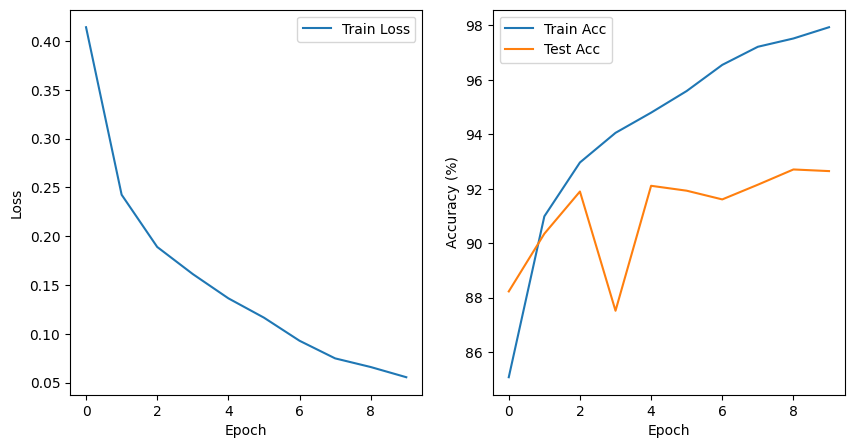

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 殘差塊實現
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                              stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                              stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                         stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = torch.relu(out)
        return out

# ResNet模型實現
class ResNet(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet, self).__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self.make_layer(64, 2, stride=1)
        self.layer2 = self.make_layer(128, 2, stride=2)
        self.layer3 = self.make_layer(256, 2, stride=2)
        self.layer4 = self.make_layer(512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def make_layer(self, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(ResidualBlock(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.maxpool(out)

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

# 訓練函數
def train_model(model, train_loader, test_loader, num_epochs, learning_rate, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

    train_losses = []
    train_accs = []
    test_accs = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total

        # 測試準確率
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        test_acc = 100. * correct / total

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {train_loss:.4f}, '
              f'Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%')

    # 繪製訓練曲線
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(test_accs, label='Test Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.show()

# 主程序
def main():
    # 設置設備
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 數據預處理
    transform = transforms.Compose([
        transforms.Resize((96, 96)),
        transforms.ToTensor(),
    ])

    # 加載數據
    train_dataset = torchvision.datasets.FashionMNIST(
        root='./data', train=True, transform=transform, download=True)
    test_dataset = torchvision.datasets.FashionMNIST(
        root='./data', train=False, transform=transform, download=True)

    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

    # 創建模型
    model = ResNet().to(device)

    # 訓練模型
    train_model(model, train_loader, test_loader,
               num_epochs=10, learning_rate=0.05, device=device)

if __name__ == '__main__':
    main()

## 小結

* 學習嵌套函數（nested function）是訓練神經網路的理想情況。在深層神經網路中，學習另一層作為恆等映射（identity function）較容易（儘管這是一個極端情況）。
* 殘差映射可以更容易地學習同一函數，例如將權重層中的參數近似為零。
* 利用殘差塊（residual blocks）可以訓練出一個有效的深層神經網路：輸入可以通過層間的殘余連接更快地向前傳播。
* 殘差網路（ResNet）對隨後的深層神經網路設計產生了深遠影響。

## 練習

1.  :numref:`fig_inception`中的Inception塊與殘差塊之間的主要區別是什麼？在刪除了Inception塊中的一些路徑之後，它們是如何相互關聯的？
1. 參考ResNet論文 :cite:`He.Zhang.Ren.ea.2016`中的表1，以實現不同的變體。
1. 對於更深層次的網路，ResNet引入了“bottleneck”架構來降低模型複雜性。請嘗試實現它。
1. 在ResNet的後續版本中，作者將“卷積層、批量規範化層和激活層”架構更改为“批量規範化層、激活層和卷積層”架構。請嘗試做這個改進。詳見 :cite:`He.Zhang.Ren.ea.2016*1`中的圖1。
1. 為什麼即使函數類是嵌套的，我們仍然要限制增加函數的複雜性呢？


[Discussions](https://discuss.d2l.ai/t/1877)
